Exploratory Data Analysis - Dataset 1
1. Basic Dataset Information
Dataset shape: 2028 rows × 11 columns

First 5 rows of data:
     age  gender department academic_year  cgpa_band  stress_score  \
0  18-22  female     eng_cs        second  2.50-2.99            29   
1  18-22    male     eng_cs         third  3.00-3.39            24   
2  18-22    male     eng_cs         third  3.00-3.39            15   
3  18-22    male     eng_cs         third  3.00-3.39            17   
4  18-22    male     eng_cs        second  2.50-2.99            32   

  stress_level  anxiety_score anxiety_level  depression_score  \
0       severe             15        severe                20   
1     moderate             12      moderate                19   
2     moderate              0       minimal                 0   
3     moderate             10      moderate                14   
4       severe             14      moderate                20   

    depression_level  
0             severe  
1  moderately_

C:\Users\HUAWEI\AppData\Local\Temp\ipykernel_14600\1041489618.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cgpa_band', y='anxiety_score', data=df1, palette='Set3')


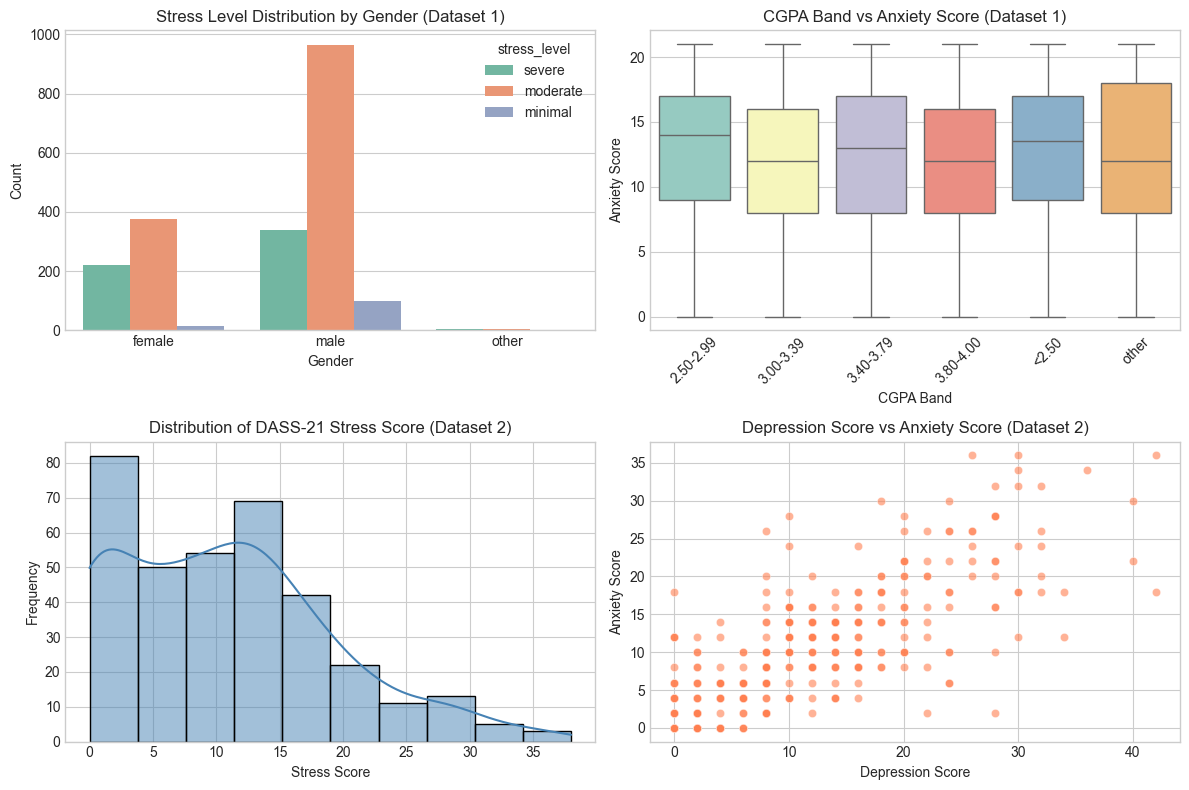


Key Comparison of Two Datasets
Dataset 1 Sample Size: 2028 (Summarized Group Data)
Dataset 2 Sample Size: 351 (DASS-21 Individual Raw Data)

Dataset 1 Focus: Mental health levels grouped by demographic factors
Dataset 2 Focus: Individual DASS-21 questionnaire scores


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
df1 = pd.read_csv("./dataset1_clean.csv")
df2 = pd.read_csv("./dataset2_clean.csv")
print("=" * 50)
print("Exploratory Data Analysis - Dataset 1")
print("=" * 50)
print("1. Basic Dataset Information")
print(f"Dataset shape: {df1.shape[0]} rows × {df1.shape[1]} columns")
print("\nFirst 5 rows of data:")
print(df1.head())
print("\nData types and missing values overview:")
print(df1.info())
key_cols_df1 = ['stress_score', 'anxiety_score', 'depression_score']
print("\n2. Descriptive Statistics for Key Mental Health Scores")
print(df1[key_cols_df1].describe().round(2))

print("\n3. Missing Values Statistics")
missing_df1 = df1.isnull().sum().sort_values(ascending=False)
missing_df1 = missing_df1[missing_df1 > 0]
if missing_df1.empty:
    print("No missing values in Dataset 1.")
else:
    print(missing_df1)

print("\n4. Stress Level Distribution by Academic Year")
stress_by_year = pd.crosstab(df1['academic_year'], df1['stress_level'])
print(stress_by_year)

plt.subplot(2, 2, 1)
sns.countplot(x='gender', hue='stress_level', data=df1, palette='Set2')
plt.title('Stress Level Distribution by Gender (Dataset 1)', fontsize=12)
plt.xlabel('Gender')
plt.ylabel('Count')

plt.subplot(2, 2, 2)
sns.boxplot(x='cgpa_band', y='anxiety_score', data=df1, palette='Set3')
plt.title('CGPA Band vs Anxiety Score (Dataset 1)', fontsize=12)
plt.xlabel('CGPA Band')
plt.ylabel('Anxiety Score')
plt.xticks(rotation=45)

print("\n" + "=" * 50)
print("Exploratory Data Analysis - Dataset 2")
print("=" * 50)

print("1. Basic Dataset Information")
print(f"Dataset shape: {df2.shape[0]} rows × {df2.shape[1]} columns")
print("\nFirst 5 rows of data:")
print(df2.head())
print("\nData types and missing values overview:")
print(df2.info())

core_cols_df2 = ['dass_depression_score', 'dass_anxiety_score', 'dass_stress_score']
print("\n2. Descriptive Statistics for DASS-21 Core Scores")
print(df2[core_cols_df2].describe().round(2))

print("\n3. Missing Values Statistics")
missing_df2 = df2.isnull().sum().sort_values(ascending=False)
missing_df2 = missing_df2[missing_df2 > 0]
if missing_df2.empty:
    print("No missing values in Dataset 2.")
else:
    print(missing_df2)

plt.subplot(2, 2, 3)
sns.histplot(df2['dass_stress_score'], kde=True, color='steelblue', bins=10)
plt.title('Distribution of DASS-21 Stress Score (Dataset 2)', fontsize=12)
plt.xlabel('Stress Score')
plt.ylabel('Frequency')

plt.subplot(2, 2, 4)
sns.scatterplot(x='dass_depression_score', y='dass_anxiety_score', data=df2, color='coral', alpha=0.6)
plt.title('Depression Score vs Anxiety Score (Dataset 2)', fontsize=12)
plt.xlabel('Depression Score')
plt.ylabel('Anxiety Score')

plt.tight_layout()
plt.show()

print("\n" + "=" * 50)
print("Key Comparison of Two Datasets")
print("=" * 50)
print(f"Dataset 1 Sample Size: {df1.shape[0]} (Summarized Group Data)")
print(f"Dataset 2 Sample Size: {df2.shape[0]} (DASS-21 Individual Raw Data)")
print(f"\nDataset 1 Focus: Mental health levels grouped by demographic factors")
print(f"Dataset 2 Focus: Individual DASS-21 questionnaire scores")